# Clasificación binaria de reingreso hospitalario a 30 días

**Micro-proyecto · Desarrollo de Soluciones · MAIA, Universidad de los Andes — Entrega 2**

Leonardo Almanza Sánchez

## Introducción

### Descripción

Este cuaderno documenta el desarrollo y la evaluación del modelo de clasificación que
responde la pregunta de negocio del proyecto:

> **¿Qué pacientes diabéticos van a reingresar al hospital dentro de los 30 días siguientes al alta?**

La respuesta alimenta una decisión concreta que se toma el día del alta: **a qué pacientes se
les programa control de seguimiento**, cuando la capacidad de hacerlo es limitada.

El modelo entrega dos salidas por paciente:

| Salida | Uso |
|---|---|
| `predict(X)` → 0 o 1 | la clasificación: reingresa o no |
| `predict_proba(X)` → probabilidad | dato de referencia para que el tablero filtre el listado |

#### Arquitectura del clasificador

1. Entrenar un clasificador binario sobre datos clínicos fuertemente desbalanceados (11,4 % de positivos).
2. Contrastar seis técnicas de balanceo de clases aplicadas **sin producir fuga de datos**.
3. Elegir la métrica de evaluación a partir del costo real de cada tipo de error.
4. Interpretar la matriz de confusión en términos operativos, no estadísticos.

### Criterio de evaluación

La proporción de reingresos tempranos es de 11,4 %. Con ese desbalance, la exactitud deja de
informar: un clasificador que responda siempre «no reingresa» acierta el **88,6 %** de las veces
sin identificar a un solo paciente en riesgo.

La métrica se deriva entonces del costo de cada error, que no es simétrico:

| Error | Qué ocurre en la práctica | Costo operativo |
|---|---|---|
| **Falso positivo** — se predice reingreso y no ocurre | se asigna seguimiento a alguien que no lo necesitaba tanto | consume un cupo de la capacidad limitada; el costo es de oportunidad y es acotado |
| **Falso negativo** — se predice alta segura y el paciente reingresa | el paciente no recibe seguimiento y vuelve | se pierde la oportunidad de intervenir: cama ocupada, costo hospitalario alto, posible deterioro del paciente y más carga al sistema |

El falso negativo es el error caro. La métrica de selección es **F2**, que pesa el doble la
sensibilidad sobre la precisión:

$$F_\beta = (1+\beta^2)\cdot\frac{\text{precisión}\cdot\text{sensibilidad}}{\beta^2\cdot\text{precisión}+\text{sensibilidad}}, \qquad \beta=2$$

No se usa la sensibilidad por sí sola porque no admite maximización: marcar a todos los pacientes
la lleva a 1,00 sin que el modelo aporte nada. F2 conserva su prioridad y penaliza esa degeneración.

### Prevención de fuga de datos

Dos fuentes de fuga condicionan el diseño y se controlan de forma explícita:

1. **Pacientes repetidos.** El 46 % de las filas pertenece a pacientes con más de un encuentro.
   Como un reingreso genera un segundo registro, reconocer al paciente equivale a conocer el
   desenlace. La partición se agrupa por `patient_nbr` y se verifica en cada corrida.
2. **Remuestreo prematuro.** Las técnicas de balanceo generan o descartan observaciones. Aplicadas
   antes de separar los conjuntos, trasladan información de evaluación hacia el entrenamiento.
   Aquí todo el remuestreo ocurre **dentro del pipeline**, de modo que se aplica solo al ajustar.

#### Inicialización

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import construccion as cons, esquema as esq
from src.models import particion as part, metricas as met, entrenamiento as ent

# Los modulos del proyecto fijan el backend "Agg" para poder generar figuras
# en la maquina remota, que no tiene pantalla. Aqui se vuelve al backend
# interactivo para que las graficas queden incrustadas en el cuaderno.
%matplotlib inline

pd.set_option("display.width", 160)
sns.set_theme(style="white")

SUPERFICIE, TINTA, SERIE, ALERTA = "#fcfcfb", "#0b0b0b", "#2a78d6", "#c8532b"
plt.rcParams.update({"figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
                     "font.size": 9, "axes.titlesize": 10})

# Servidor de MLflow del proyecto. Cambiar por la IP vigente de la EC2:
# la instancia usa IP elastica y cambia al reiniciarse.
URI_MLFLOW = "http://3.215.79.195:8050"

print("criterio de umbral :", esq.CRITERIO_UMBRAL)
print("semilla            :", esq.SEMILLA)

criterio de umbral : f2
semilla            : 42


#### Cargar los datos

La lectura desactiva la interpretación automática de nulos de pandas. El archivo marca el dato
ausente con `?`, y las columnas `A1Cresult` y `max_glu_serum` traen el texto literal `None`, que
**no** significa dato faltante sino que el examen no se ordenó — información clínica que el EDA
de la Entrega 1 identificó y que no debe destruirse (EDA 1.2).

In [2]:
crudos = cons.cargar()
fallas = cons.verificar_carga(crudos)
print("comprobaciones fallidas:", fallas or "ninguna")
print(f"registros crudos: {len(crudos):,}  columnas: {crudos.shape[1]}")

comprobaciones fallidas: ninguna
registros crudos: 101,766  columnas: 50


Se aplican las exclusiones definidas en el EDA 5.2 y 5.3: los egresos por fallecimiento, que no
admiten reingreso, y los egresos a hospicio, donde programar un control no es la intervención
pertinente.

In [3]:
trabajo = cons.conjunto_de_trabajo(crudos)

print(f"conjunto de trabajo : {len(trabajo):,} egresos")
print(f"pacientes distintos : {trabajo['patient_nbr'].nunique():,}")
print(f"tasa de reingreso   : {trabajo[esq.OBJETIVO].mean():.4f}")

conjunto de trabajo : 99,343 egresos
pacientes distintos : 69,990
tasa de reingreso   : 0.1139


#### Visualización de datos

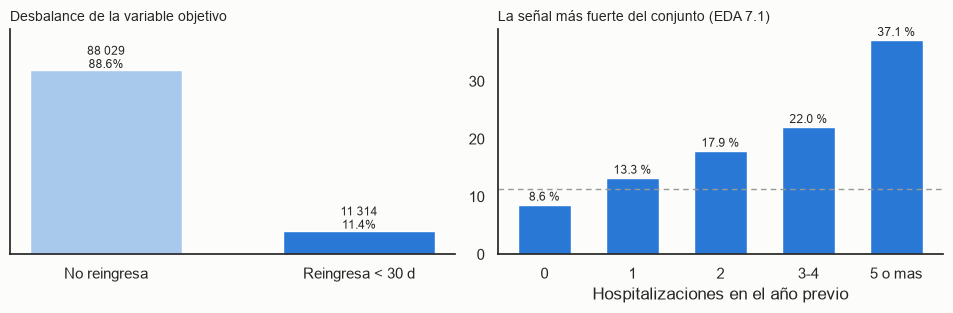

In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(9.6, 3.2))

conteo = trabajo[esq.OBJETIVO].value_counts().sort_index()
ejes[0].bar(["No reingresa", "Reingresa < 30 d"], conteo.values,
            color=["#a8c8ec", SERIE], width=0.6)
for i, v in enumerate(conteo.values):
    ejes[0].text(i, v + 900, f"{v:,}".replace(",", " ") + f"\n{v/len(trabajo):.1%}",
                 ha="center", fontsize=8.5)
ejes[0].set_ylim(0, conteo.max() * 1.22)
ejes[0].set_yticks([])
ejes[0].set_title("Desbalance de la variable objetivo", loc="left")

tramos = pd.cut(trabajo["number_inpatient"], [-1, 0, 1, 2, 4, 10**6],
                labels=["0", "1", "2", "3-4", "5 o mas"])
tasa = trabajo.groupby(tramos, observed=True)[esq.OBJETIVO].mean() * 100
ejes[1].bar(range(len(tasa)), tasa.values, color=SERIE, width=0.6)
for i, v in enumerate(tasa.values):
    ejes[1].text(i, v + 0.7, f"{v:.1f} %", ha="center", fontsize=8.5)
ejes[1].axhline(trabajo[esq.OBJETIVO].mean() * 100, color="#9a9992",
                linestyle=(0, (4, 3)), linewidth=1)
ejes[1].set_xticks(range(len(tasa)), tasa.index)
ejes[1].set_xlabel("Hospitalizaciones en el año previo")
ejes[1].set_title("La señal más fuerte del conjunto (EDA 7.1)", loc="left")

for ax in ejes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

La clase positiva es minoritaria en una proporción de casi ocho a uno. El panel derecho muestra
por qué el problema es aprendible pese a ello: el historial de hospitalizaciones del año previo
separa la tasa de reingreso desde 8,6 % hasta 37,1 %, un gradiente monótono de más de cuatro veces.

#### División de los conjuntos de entrenamiento

La partición **no** es aleatoria por fila. El conjunto tiene 16 341 pacientes con más de un
encuentro, y el 46 % de las filas les pertenece. Una partición aleatoria dejaría encuentros del
mismo paciente a ambos lados y comprometería el 41,5 % de las filas de evaluación (EDA 8.1).

La razón es circular: si un paciente reingresa antes de 30 días, ese reingreso **genera** un
segundo registro en el conjunto. Reconocer al paciente equivale entonces a conocer el desenlace.

In [5]:
X, y, grupos = cons.matriz(trabajo)
X_ent, X_eva, y_ent, y_eva, g_ent, g_eva = part.particionar(X, y, grupos)

print(f"predictoras   : {X.shape[1]}")
print(f"entrenamiento : {len(X_ent):,} filas   tasa {y_ent.mean():.4f}")
print(f"evaluacion    : {len(X_eva):,} filas   tasa {y_eva.mean():.4f}")
print("fuga de pacientes:", part.verificar_particion(g_ent, g_eva) or "ninguna")

predictoras   : 32
entrenamiento : 79,522 filas   tasa 0.1145
evaluacion    : 19,821 filas   tasa 0.1113
fuga de pacientes: ninguna


### Creación del modelo de clasificación

Se entrena un **bosque aleatorio**: un conjunto de árboles de decisión ajustados sobre muestras
distintas de los datos, cuyo voto se promedia. Reduce la varianza de un árbol individual y maneja
sin dificultad la mezcla de variables numéricas y categóricas de este conjunto.

El umbral de decisión **no se hereda de `predict()`**. Con 11,4 % de positivos, casi ningún
paciente supera 0,5 y el clasificador termina marcando a muy pocos. Se elige por validación sobre
una porción reservada del entrenamiento, maximizando F2, y se fija en el artefacto.

In [6]:
TECNICA = "peso"        # ganadora de src/models/balanceo.py
PESO_POSITIVO = 5       # mejor valor del barrido de hiperparametros

bosque = ent.armar_estimador(
    X, ent.CATALOGO["bosque"]["constructor"](class_weight={0: 1, 1: PESO_POSITIVO}), TECNICA
)

bosque.fit(X_ent, y_ent)

# El umbral es fijo: se mantiene constante entre configuraciones para que
# la comparacion de hiperparametros sea legitima.
umbral = esq.UMBRAL_FIJO

probabilidades = bosque.predict_proba(X_eva)[:, 1]
y_predicho = (probabilidades >= umbral).astype(int)

print(f"tecnica {TECNICA} (peso {PESO_POSITIVO}) · umbral fijo {umbral:.2f}")

tecnica peso (peso 5) · umbral fijo 0.30


## Resultados

### Desempeño del clasificador

La matriz de confusión es el instrumento central del análisis: cada cuadrante corresponde a una
consecuencia operativa distinta y sus costos no son intercambiables.

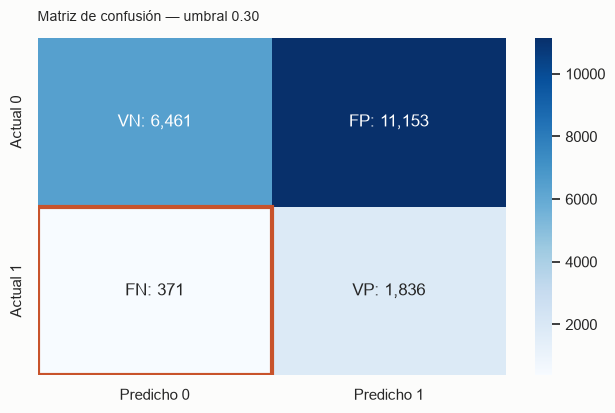

In [7]:
from sklearn.metrics import confusion_matrix

resultados = met.evaluar(y_eva, probabilidades, umbral)
conteos = met.matriz_confusion(y_eva, y_predicho)
vp, fp = conteos["verdaderos_positivos"], conteos["falsos_positivos"]
fn, vn = conteos["falsos_negativos"], conteos["verdaderos_negativos"]

cm = confusion_matrix(y_eva, y_predicho)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"],
                     columns=["Predicho 0", "Predicho 1"])

etiquetas = np.array([[f"VN: {vn:,}", f"FP: {fp:,}"],
                      [f"FN: {fn:,}", f"VP: {vp:,}"]]).astype(str)

plt.figure(figsize=(6.4, 4.2))
ax = sns.heatmap(cm_df, annot=etiquetas, fmt="", cmap="Blues",
                 annot_kws={"fontsize": 12})

# El falso negativo es el error caro: se resalta su casilla.
ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False, edgecolor=ALERTA, linewidth=3))

ax.set_title(f"Matriz de confusión — umbral {umbral:.2f}", loc="left", pad=12)
plt.tight_layout()
plt.show()

#### Lectura operativa de cada cuadrante

In [8]:
total_positivos = int(y_eva.sum())

print("VP: verdadero positivo  ", f"{vp:>6,}", " reingreso anticipado; el seguimiento llega a quien lo necesita")
print("FP: falso positivo      ", f"{fp:>6,}", " se consume un cupo de seguimiento en quien no iba a reingresar")
print("FN: falso negativo      ", f"{fn:>6,}", " el paciente sale sin control y reingresa — error caro")
print("VN: verdadero negativo  ", f"{vn:>6,}", " alta sin seguimiento, correctamente")

print(f"\nDe los {total_positivos:,} pacientes que reingresaron:")
print(f"   detectados : {vp:>6,}  ({vp/total_positivos:.1%})")
print(f"   escapados  : {fn:>6,}  ({fn/total_positivos:.1%})")

print(f"\nSeguimientos programados : {vp+fp:>6,}  ({(vp+fp)/len(y_eva):.1%} de los egresos)")
print(f"   acertados             : {vp:>6,}  (precision {resultados['precision']:.1%})")
print(f"   seguimientos por acierto: {resultados['seguimientos_por_acierto']}")

VP: verdadero positivo    1,836  reingreso anticipado; el seguimiento llega a quien lo necesita
FP: falso positivo       11,153  se consume un cupo de seguimiento en quien no iba a reingresar
FN: falso negativo          371  el paciente sale sin control y reingresa — error caro
VN: verdadero negativo    6,461  alta sin seguimiento, correctamente

De los 2,207 pacientes que reingresaron:
   detectados :  1,836  (83.2%)
   escapados  :    371  (16.8%)

Seguimientos programados : 12,989  (65.5% de los egresos)
   acertados             :  1,836  (precision 14.1%)
   seguimientos por acierto: 7.07


#### Métricas derivadas

In [9]:
tabla = pd.DataFrame([
    ("Sensibilidad (recall)", resultados["sensibilidad"], "fracción de reingresos detectados"),
    ("Precisión", resultados["precision"], "fracción de aciertos entre los marcados"),
    ("Especificidad", resultados["especificidad"], "fracción de no-reingresos bien clasificados"),
    ("F2", resultados["f2"], "pesa el doble la sensibilidad — métrica principal"),
    ("F1", resultados["f1"], "equilibrio entre precisión y sensibilidad"),
    ("Exactitud balanceada", resultados["exactitud_balanceada"], "promedio de sensibilidad y especificidad"),
    ("Exactitud", resultados["exactitud"], "engañosa aquí: el trivial alcanza 0,886"),
    ("ROC-AUC", resultados["roc_auc"], "separación, independiente del umbral"),
    ("Brier", resultados["brier"], "calidad de la probabilidad que usa el tablero"),
], columns=["métrica", "valor", "lectura"])
display(tabla.style.format({"valor": "{:.4f}"}).hide(axis="index"))

métrica,valor,lectura
Sensibilidad (recall),0.8319,fracción de reingresos detectados
Precisión,0.1414,fracción de aciertos entre los marcados
Especificidad,0.3668,fracción de no-reingresos bien clasificados
F2,0.4208,pesa el doble la sensibilidad — métrica principal
F1,0.2416,equilibrio entre precisión y sensibilidad
Exactitud balanceada,0.5994,promedio de sensibilidad y especificidad
Exactitud,0.4186,"engañosa aquí: el trivial alcanza 0,886"
ROC-AUC,0.6706,"separación, independiente del umbral"
Brier,0.1528,calidad de la probabilidad que usa el tablero


### El umbral: la palanca sobre los falsos negativos

Bajar el umbral marca más pacientes, reduce los falsos negativos y aumenta los falsos positivos.
El gráfico muestra ese intercambio y dónde queda el punto elegido.

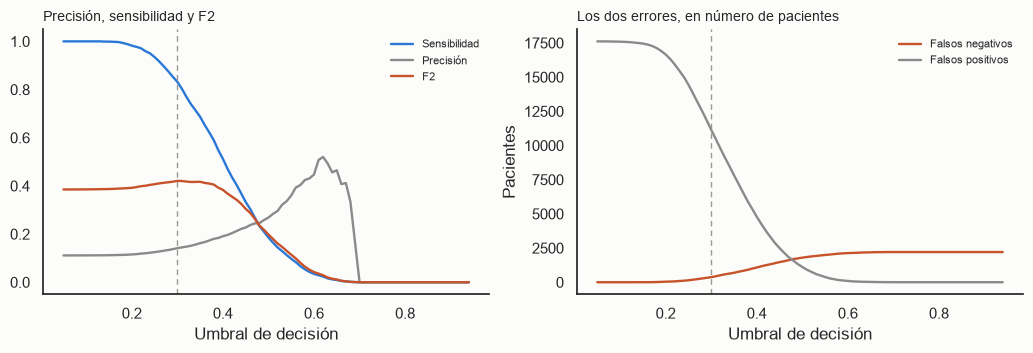

In [10]:
barrido = met.barrido_umbral(y_eva, probabilidades)

fig, ejes = plt.subplots(1, 2, figsize=(10.4, 3.6))

for col, color, etq in [("sensibilidad", SERIE, "Sensibilidad"),
                        ("precision", "#8a8a8a", "Precisión"),
                        ("f2", ALERTA, "F2")]:
    ejes[0].plot(barrido["umbral"], barrido[col], color=color, linewidth=1.7, label=etq)
ejes[0].axvline(umbral, color="#9a9992", linestyle=(0, (4, 3)), linewidth=1)
ejes[0].set_xlabel("Umbral de decisión")
ejes[0].set_title("Precisión, sensibilidad y F2", loc="left")
ejes[0].legend(frameon=False, fontsize=8)

ejes[1].plot(barrido["umbral"], barrido["falsos_negativos"], color=ALERTA,
             linewidth=1.7, label="Falsos negativos")
ejes[1].plot(barrido["umbral"], barrido["falsos_positivos"], color="#8a8a8a",
             linewidth=1.7, label="Falsos positivos")
ejes[1].axvline(umbral, color="#9a9992", linestyle=(0, (4, 3)), linewidth=1)
ejes[1].set_xlabel("Umbral de decisión")
ejes[1].set_ylabel("Pacientes")
ejes[1].set_title("Los dos errores, en número de pacientes", loc="left")
ejes[1].legend(frameon=False, fontsize=8)

for ax in ejes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

### Contraste con la referencia trivial

Un clasificador sin capacidad predictiva sirve de referencia para dimensionar el aporte real del
modelo y para justificar por qué la exactitud no se usa como criterio.

In [11]:
from sklearn.dummy import DummyClassifier

trivial = DummyClassifier(strategy="prior").fit(X_ent, y_ent)
p_trivial = trivial.predict_proba(X_eva)[:, 1]
r_trivial = met.evaluar(y_eva, p_trivial, 0.5)

comparacion = pd.DataFrame([
    {"modelo": "Trivial (siempre 'no reingresa')", **{k: r_trivial[k] for k in
     ("exactitud", "sensibilidad", "f2", "falsos_negativos")}},
    {"modelo": "Bosque aleatorio", **{k: resultados[k] for k in
     ("exactitud", "sensibilidad", "f2", "falsos_negativos")}},
])
display(comparacion.style.format({"exactitud": "{:.4f}", "sensibilidad": "{:.4f}",
                                  "f2": "{:.4f}"}).hide(axis="index"))

modelo,exactitud,sensibilidad,f2,falsos_negativos
Trivial (siempre 'no reingresa'),0.8887,0.0000,0.0000,2207
Bosque aleatorio,0.4186,0.8319,0.4208,371


**Respuesta.** El clasificador trivial alcanza una exactitud de 0,886 sin detectar a un solo
paciente en riesgo: deja escapar a **todos** los que reingresan. El bosque tiene una exactitud
*menor* y sin embargo es el único útil. La exactitud premia acertar sobre la clase mayoritaria,
que es precisamente la que no interesa.

### Efecto de las técnicas de balanceo

Siete alternativas contrastadas al mismo umbral, todas aplicadas dentro del pipeline. Los
resultados provienen de `python -m src.models.balanceo` y se leen de MLflow para que el análisis
y las corridas no se desincronicen.

In [12]:
# Resultados producidos por: python -m src.models.balanceo# Se leen de MLflow para que el cuaderno y las corridas no se desincronicen.import mlflowmlflow.set_tracking_uri(URI_MLFLOW)cliente = mlflow.MlflowClient()exp = cliente.get_experiment_by_name("reingreso-30d-balanceo")corridas = mlflow.search_runs([exp.experiment_id])vista = corridas[corridas["params.desbalance"].notna()][[    "params.desbalance", "metrics.umbral", "metrics.f2", "metrics.sensibilidad",    "metrics.precision", "metrics.falsos_negativos", "metrics.falsos_positivos"]]vista.columns = ["técnica", "umbral", "F2", "sensibilidad", "precisión", "FN", "FP"]display(vista.sort_values("F2", ascending=False).style.hide(axis="index"))

### Costo de los errores

La razón entre el costo de un falso negativo y el de un falso positivo determina dónde conviene
cortar. Se declara como parámetro y no como constante: cada institución tiene su propia relación
entre el costo de un control posterior al alta y el de una readmisión.

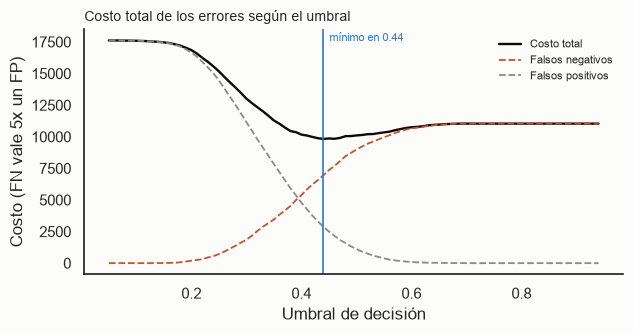

umbral de mínimo costo : 0.440
umbral elegido por F2  : 0.300


In [13]:
costos = met.umbral_de_minimo_costo(
    y_eva, probabilidades,
    costo_falso_positivo=esq.COSTO_FALSO_POSITIVO,
    costo_falso_negativo=esq.COSTO_FALSO_NEGATIVO,
)
optimo = costos.loc[costos["costo_total"].idxmin()]

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(costos["umbral"], costos["costo_total"], color=TINTA, linewidth=1.7, label="Costo total")
ax.plot(costos["umbral"], costos["costo_falsos_negativos"], color=ALERTA,
        linewidth=1.3, linestyle="--", label="Falsos negativos")
ax.plot(costos["umbral"], costos["costo_falsos_positivos"], color="#8a8a8a",
        linewidth=1.3, linestyle="--", label="Falsos positivos")
ax.axvline(optimo["umbral"], color=SERIE, linewidth=1.2)
ax.text(optimo["umbral"], ax.get_ylim()[1]*0.95, f"  mínimo en {optimo['umbral']:.2f}",
        fontsize=8, color=SERIE)
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel(f"Costo (FN vale {esq.COSTO_FALSO_NEGATIVO:.0f}x un FP)")
ax.set_title("Costo total de los errores según el umbral", loc="left")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print(f"umbral de mínimo costo : {optimo['umbral']:.3f}")
print(f"umbral elegido por F2  : {umbral:.3f}")

**Interpretación.** La razón cinco a uno entre los dos errores es un parámetro explícito, no una
constante escondida. Cada institución tiene su propia relación entre el costo de un control
posterior al alta y el de una readmisión, y el umbral óptimo se mueve con ella. Que el umbral
elegido por F2 quede cerca del de mínimo costo indica que la elección de métrica es coherente con
la estructura de costos declarada.

## Observaciones y conclusiones

*(pendiente: se completa con los resultados definitivos del barrido de hiperparámetros)*